In [ ]:
!pip install pyagrum
!pip install numpy
!pip install causal-learn
!pip install pandas
!pip install pingouin
!pip install bnlearn
!pip install graphviz
!pip install IPython

In [1]:
import sys
import os
sys.path.append(os.getcwd())

In [2]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import bnlearn as bn
from FCI_pyagrum import *
import graphviz
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz, chisq
from causallearn.utils.GraphUtils import GraphUtils
from IPython.display import Image, display

C:\Users\vuale\AppData\Roaming\Python\Python313\site-packages\bnlearn\__init__.py:22: RuntimeWarning: [bnlearn] Using 'threading' backend instead of 'loky' because Windows + Python 3.13.2 causes joblib/loky crashes.
  warnings.warn(


In [3]:
model = bn.import_DAG("asia")

[bnlearn] >Import <asia>
[bnlearn] >Loading bif file <C:\Users\vuale\AppData\Roaming\Python\Python313\site-packages\datazets\data\asia.bif>
[bnlearn] >[CPD > Validate] >[Node asia] >OK
[bnlearn] >[CPD > Validate] >[Node bronc] >OK
[bnlearn] >[CPD > Validate] >[Node dysp] >OK
[bnlearn] >[CPD > Validate] >[Node either] >OK
[bnlearn] >[CPD > Validate] >[Node lung] >OK
[bnlearn] >[CPD > Validate] >[Node smoke] >OK
[bnlearn] >[CPD > Validate] >[Node tub] >OK
[bnlearn] >[CPD > Validate] >[Node xray] >OK


[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


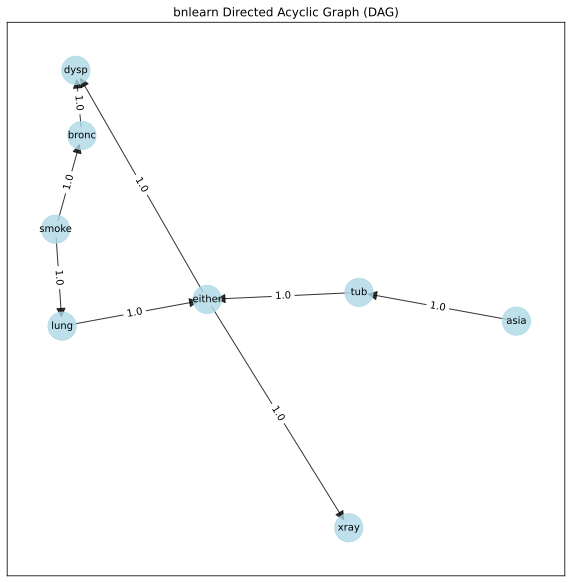

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'asia': array([ 0.26037954, -0.18175514]),
  'tub': array([ 0.12513541, -0.06785314]),
  'either': array([-0.00528527, -0.09583199]),
  'smoke': array([-0.13555617,  0.18237055]),
  'lung': array([-0.12994109, -0.20164478]),
  'bronc': array([-0.11293298,  0.55327621]),
  'dysp': array([-0.11817126,  0.8114383 ]),
  'xray': array([ 0.11637181, -1.        ])},
 'G': <networkx.classes.digraph.DiGraph at 0x2b0f20730e0>,
 'node_properties': {'asia': {'node_color': '#ADD8E6', 'node_size': 800},
  'tub': {'node_color': '#ADD8E6', 'node_size': 800},
  'smoke': {'node_color': '#ADD8E6', 'node_size': 800},
  'lung': {'node_color': '#ADD8E6', 'node_size': 800},
  'bronc': {'node_color': '#ADD8E6', 'node_size': 800},
  'either': {'node_color': '#ADD8E6', 'node_size': 800},
  'xray': {'node_color': '#ADD8E6', 'node_size': 800},
  'dysp': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties'

In [4]:
bn.plot(model)

In [5]:
df = bn.sampling(model, n=100000)
df

,asia,tub,smoke,lung,bronc,either,xray,dysp
0,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,0
2,1,1,1,1,0,1,1,0
3,1,1,0,1,0,1,1,1
4,1,1,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...
99995,1,1,1,1,0,1,1,0
99996,1,1,0,1,1,1,1,1
99997,1,1,1,1,1,1,1,1
99998,1,1,0,1,0,1,1,0


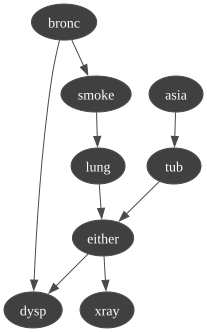

In [6]:
learner = gum.BNLearner(df)
learner.useMIIC()
bn_miic = learner.learnBN()
gnb.showBN(bn_miic)

  0%|          | 0/8 [00:00<?, ?it/s]

0 dep 1 | () with p-value 0.000000

0 ind 2 | () with p-value 0.626408

0 ind 3 | () with p-value 0.507918

0 ind 4 | () with p-value 0.942387

0 dep 5 | () with p-value 0.000338

0 dep 6 | () with p-value 0.006342

0 ind 7 | () with p-value 0.076053

1 dep 0 | () with p-value 0.000000

1 ind 2 | () with p-value 0.696745

1 ind 3 | () with p-value 0.677261

1 ind 4 | () with p-value 0.720056

1 dep 5 | () with p-value 0.000000

1 dep 6 | () with p-value 0.000000

1 dep 7 | () with p-value 0.000000

2 ind 0 | () with p-value 0.626408

2 ind 1 | () with p-value 0.696745

2 dep 3 | () with p-value 0.000000

2 dep 4 | () with p-value 0.000000

2 dep 5 | () with p-value 0.000000

2 dep 6 | () with p-value 0.000000

2 dep 7 | () with p-value 0.000000

3 ind 0 | () with p-value 0.507918

3 ind 1 | () with p-value 0.677261

3 dep 2 | () with p-value 0.000000

3 dep 4 | () with p-value 0.000000

3 dep 5 | () with p-value 0.000000

3 dep 6 | () with p-value 0.000000

3 dep 7 | () with p-value 0.

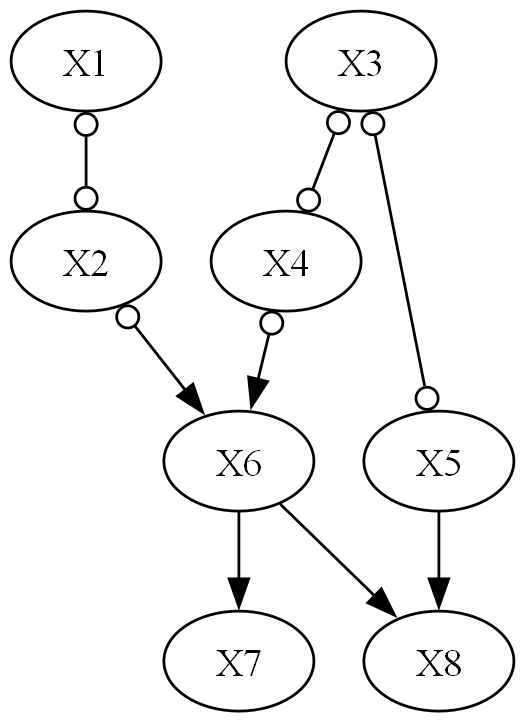

In [7]:
graph, sep_sets = fci(
    df.to_numpy(),
    ci_test=fisherz,
    alpha=0.05,
    verbose=True,
)
node_names = list(df.columns)
pdy = GraphUtils.to_pydot(graph)
display(Image(pdy.create_png()))

[[' ' 'o' ' ' ' ' ' ' ' ' ' ' ' ']
 ['o' ' ' ' ' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' ' ' 'o' 'o' ' ' ' ' ' ']
 [' ' ' ' 'o' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' '-' ' ' ' ' ' ' ' ' '>']
 [' ' '-' ' ' '-' ' ' ' ' '>' '>']
 [' ' ' ' ' ' ' ' ' ' '-' ' ' ' ']
 [' ' ' ' ' ' ' ' '-' '-' ' ' ' ']]


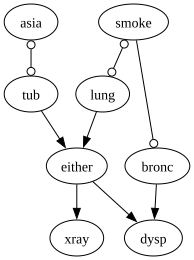

In [8]:
fci_final = run_FCI(df, 0.05, useGum=False)
print(fci_final.matrix)
graph = fci_final.toDot()
graph
# pdag = fci_final.return_PDAG()
# graph = graphviz.Source(pdag.toDot())
# graph

[[' ' 'o' ' ' ' ' ' ' ' ' ' ' ' ']
 ['o' ' ' ' ' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' ' ' 'o' 'o' ' ' ' ' ' ']
 [' ' ' ' 'o' ' ' ' ' '>' ' ' '>']
 [' ' ' ' '-' ' ' ' ' ' ' ' ' '>']
 [' ' '-' ' ' '-' ' ' ' ' '>' '>']
 [' ' ' ' ' ' ' ' ' ' '-' ' ' ' ']
 [' ' ' ' ' ' '-' '-' '-' ' ' ' ']]


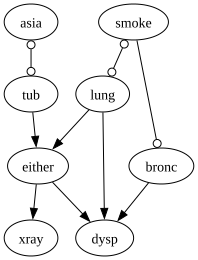

In [9]:
rfci = run_RFCI(df, 0.05, useGum=False)
print(rfci.matrix)
graph = rfci.toDot()
graph
# pdag = rfci.return_PDAG()
# graph = graphviz.Source(pdag.toDot())
# graph